## 1. Imports and Setup

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedKFold

AUDIOSET_DIR = Path("data/audio/AudioSet")
CLIPS_DIR    = AUDIOSET_DIR / "clips"
SYNTH_DIR    = AUDIOSET_DIR / "synthesised"
SYNTH_DIR.mkdir(parents=True, exist_ok=True)

CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
CIFAR10_LABEL_MAP = {c: i for i, c in enumerate(CIFAR10_CLASSES)}

SAMPLE_RATE     = 16000
DURATION        = 10       # AudioSet clips are 10 seconds
MAX_PER_CLASS   = 100

print("Setup complete")
print(f"Sample rate: {SAMPLE_RATE}Hz")
print(f"Duration:    {DURATION}s")
print(f"Max per class: {MAX_PER_CLASS}")

Setup complete
Sample rate: 16000Hz
Duration:    10s
Max per class: 100


## 2. Inventory Downloaded Clips

In [2]:
inventory = []

for cifar_class in CIFAR10_CLASSES:
    if cifar_class == 'deer':
        continue
    cls_dir = CLIPS_DIR / cifar_class
    if not cls_dir.exists():
        print(f"⚠️  {cifar_class} directory not found")
        continue
    files = sorted(cls_dir.glob("*.wav"))
    for f in files:
        inventory.append({
            'filepath'   : str(f),
            'cifar_class': cifar_class,
            'cifar_label': CIFAR10_LABEL_MAP[cifar_class],
            'synthesised': False
        })

inventory_df = pd.DataFrame(inventory)

print("Raw downloaded clips per class:")
print("-" * 35)
for cls in CIFAR10_CLASSES:
    if cls == 'deer':
        print(f"{'deer':<15} → synthesis pending")
        continue
    count = len(inventory_df[inventory_df['cifar_class'] == cls])
    print(f"{cls:<15} → {count} clips")
print(f"\nTotal raw clips: {len(inventory_df)}")

Raw downloaded clips per class:
-----------------------------------
airplane        → 108 clips
automobile      → 176 clips
bird            → 165 clips
cat             → 167 clips
deer            → synthesis pending
dog             → 167 clips
frog            → 93 clips
horse           → 125 clips
ship            → 178 clips
truck           → 150 clips

Total raw clips: 1329


## 3. Cap at 100 Per Class

In [3]:
np.random.seed(42)

capped_rows = []

for cifar_class in CIFAR10_CLASSES:
    if cifar_class == 'deer':
        continue
    subset = inventory_df[
        inventory_df['cifar_class'] == cifar_class
    ]
    # sample min(MAX_PER_CLASS, available)
    n      = min(MAX_PER_CLASS, len(subset))
    subset = subset.sample(n=n, random_state=42)
    capped_rows.append(subset)

capped_df = pd.concat(capped_rows, ignore_index=True)

print("Capped clips per class:")
print("-" * 35)
for cls in CIFAR10_CLASSES:
    if cls == 'deer':
        print(f"{'deer':<15} → synthesis pending")
        continue
    count = len(capped_df[capped_df['cifar_class'] == cls])
    print(f"{cls:<15} → {count} clips")
print(f"\nTotal capped clips: {len(capped_df)}")

Capped clips per class:
-----------------------------------
airplane        → 100 clips
automobile      → 100 clips
bird            → 100 clips
cat             → 100 clips
deer            → synthesis pending
dog             → 100 clips
frog            → 93 clips
horse           → 100 clips
ship            → 100 clips
truck           → 100 clips

Total capped clips: 893


## 4. Deer Synthesis via Augmentation

In [4]:
DEER_SYNTH_DIR = SYNTH_DIR / "deer"
DEER_SYNTH_DIR.mkdir(parents=True, exist_ok=True)

# Use horse, dog, cat as source — animal sounds
# More appropriate than farm animals used in ESC-50 experiment
source_classes = ['horse', 'dog', 'cat']
source_files   = capped_df[
    capped_df['cifar_class'].isin(source_classes)
]['filepath'].tolist()

print(f"Source files available: {len(source_files)}")
print(f"Generating {MAX_PER_CLASS} deer samples via augmentation...")

np.random.seed(42)
n_samples    = SAMPLE_RATE * DURATION
generated    = 0

for i in range(MAX_PER_CLASS):
    # pick random source animal sound
    src_path = source_files[i % len(source_files)]

    y, sr = librosa.load(src_path, sr=SAMPLE_RATE, 
                         duration=float(DURATION))

    # pad or trim to fixed length
    if len(y) < n_samples:
        y = np.pad(y, (0, n_samples - len(y)))
    else:
        y = y[:n_samples]

    # augmentation chain
    # 1. pitch shift — random between -3 and +3 semitones
    pitch_shift = np.random.uniform(-3, 3)
    y = librosa.effects.pitch_shift(y, sr=SAMPLE_RATE, 
                                     n_steps=pitch_shift)

    # 2. time stretch — random between 0.85 and 1.15
    stretch = np.random.uniform(0.85, 1.15)
    y = librosa.effects.time_stretch(y, rate=stretch)

    # 3. add low level noise for variation
    noise = np.random.normal(0, 0.005, len(y))
    y     = y + noise

    # re-trim after stretch
    if len(y) < n_samples:
        y = np.pad(y, (0, n_samples - len(y)))
    else:
        y = y[:n_samples]

    # normalise
    y = y / (np.max(np.abs(y)) + 1e-9)

    filepath = DEER_SYNTH_DIR / f"deer_aug_{i:03d}.wav"
    sf.write(str(filepath), y, SAMPLE_RATE)
    generated += 1

print(f"✅ Generated {generated} deer samples")
print(f"Saved to: {DEER_SYNTH_DIR}")

Source files available: 300
Generating 100 deer samples via augmentation...


c:\Edu\VATSA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Generated 100 deer samples
Saved to: data\audio\AudioSet\synthesised\deer


## 5. Add Deer to Final Dataset

In [5]:
deer_files = sorted(DEER_SYNTH_DIR.glob("*.wav"))

deer_rows = []
for filepath in deer_files:
    deer_rows.append({
        'filepath'   : str(filepath),
        'cifar_class': 'deer',
        'cifar_label': CIFAR10_LABEL_MAP['deer'],
        'synthesised': True
    })

deer_df  = pd.DataFrame(deer_rows)
final_df = pd.concat([capped_df, deer_df], ignore_index=True)

print("Final dataset per class:")
print("-" * 35)
for cls in CIFAR10_CLASSES:
    count = len(final_df[final_df['cifar_class'] == cls])
    flag  = " (synthesised)" if cls == 'deer' else ""
    print(f"{cls:<15} → {count} clips{flag}")

print(f"\nTotal samples:       {len(final_df)}")
print(f"Real samples:        {(~final_df['synthesised']).sum()}")
print(f"Synthesised samples: {final_df['synthesised'].sum()}")

# Save final manifest
final_df.to_csv(AUDIOSET_DIR / "final_dataset.csv", index=False)
print("\n✅ Saved final_dataset.csv")

Final dataset per class:
-----------------------------------
airplane        → 100 clips
automobile      → 100 clips
bird            → 100 clips
cat             → 100 clips
deer            → 100 clips (synthesised)
dog             → 100 clips
frog            → 93 clips
horse           → 100 clips
ship            → 100 clips
truck           → 100 clips

Total samples:       993
Real samples:        893
Synthesised samples: 100

✅ Saved final_dataset.csv


## 6. Verify Audio Quality — Sample Check

In [6]:
print("Verifying audio files load correctly...")
errors  = []
lengths = []

for i, row in final_df.iterrows():
    try:
        y, sr = librosa.load(row['filepath'], 
                             sr=SAMPLE_RATE, duration=float(DURATION))
        lengths.append(len(y))
    except Exception as e:
        errors.append((row['filepath'], str(e)))

print(f"Files checked:  {len(final_df)}")
print(f"Load errors:    {len(errors)}")
print(f"Min length:     {min(lengths)} samples ({min(lengths)/SAMPLE_RATE:.1f}s)")
print(f"Max length:     {max(lengths)} samples ({max(lengths)/SAMPLE_RATE:.1f}s)")

if errors:
    print("\nError files:")
    for path, err in errors:
        print(f"  {path}: {err}")
else:
    print("\n✅ All files load cleanly")

Verifying audio files load correctly...
Files checked:  993
Load errors:    0
Min length:     20062 samples (1.3s)
Max length:     160000 samples (10.0s)

✅ All files load cleanly


## 7. Visualise One Sample Per Class

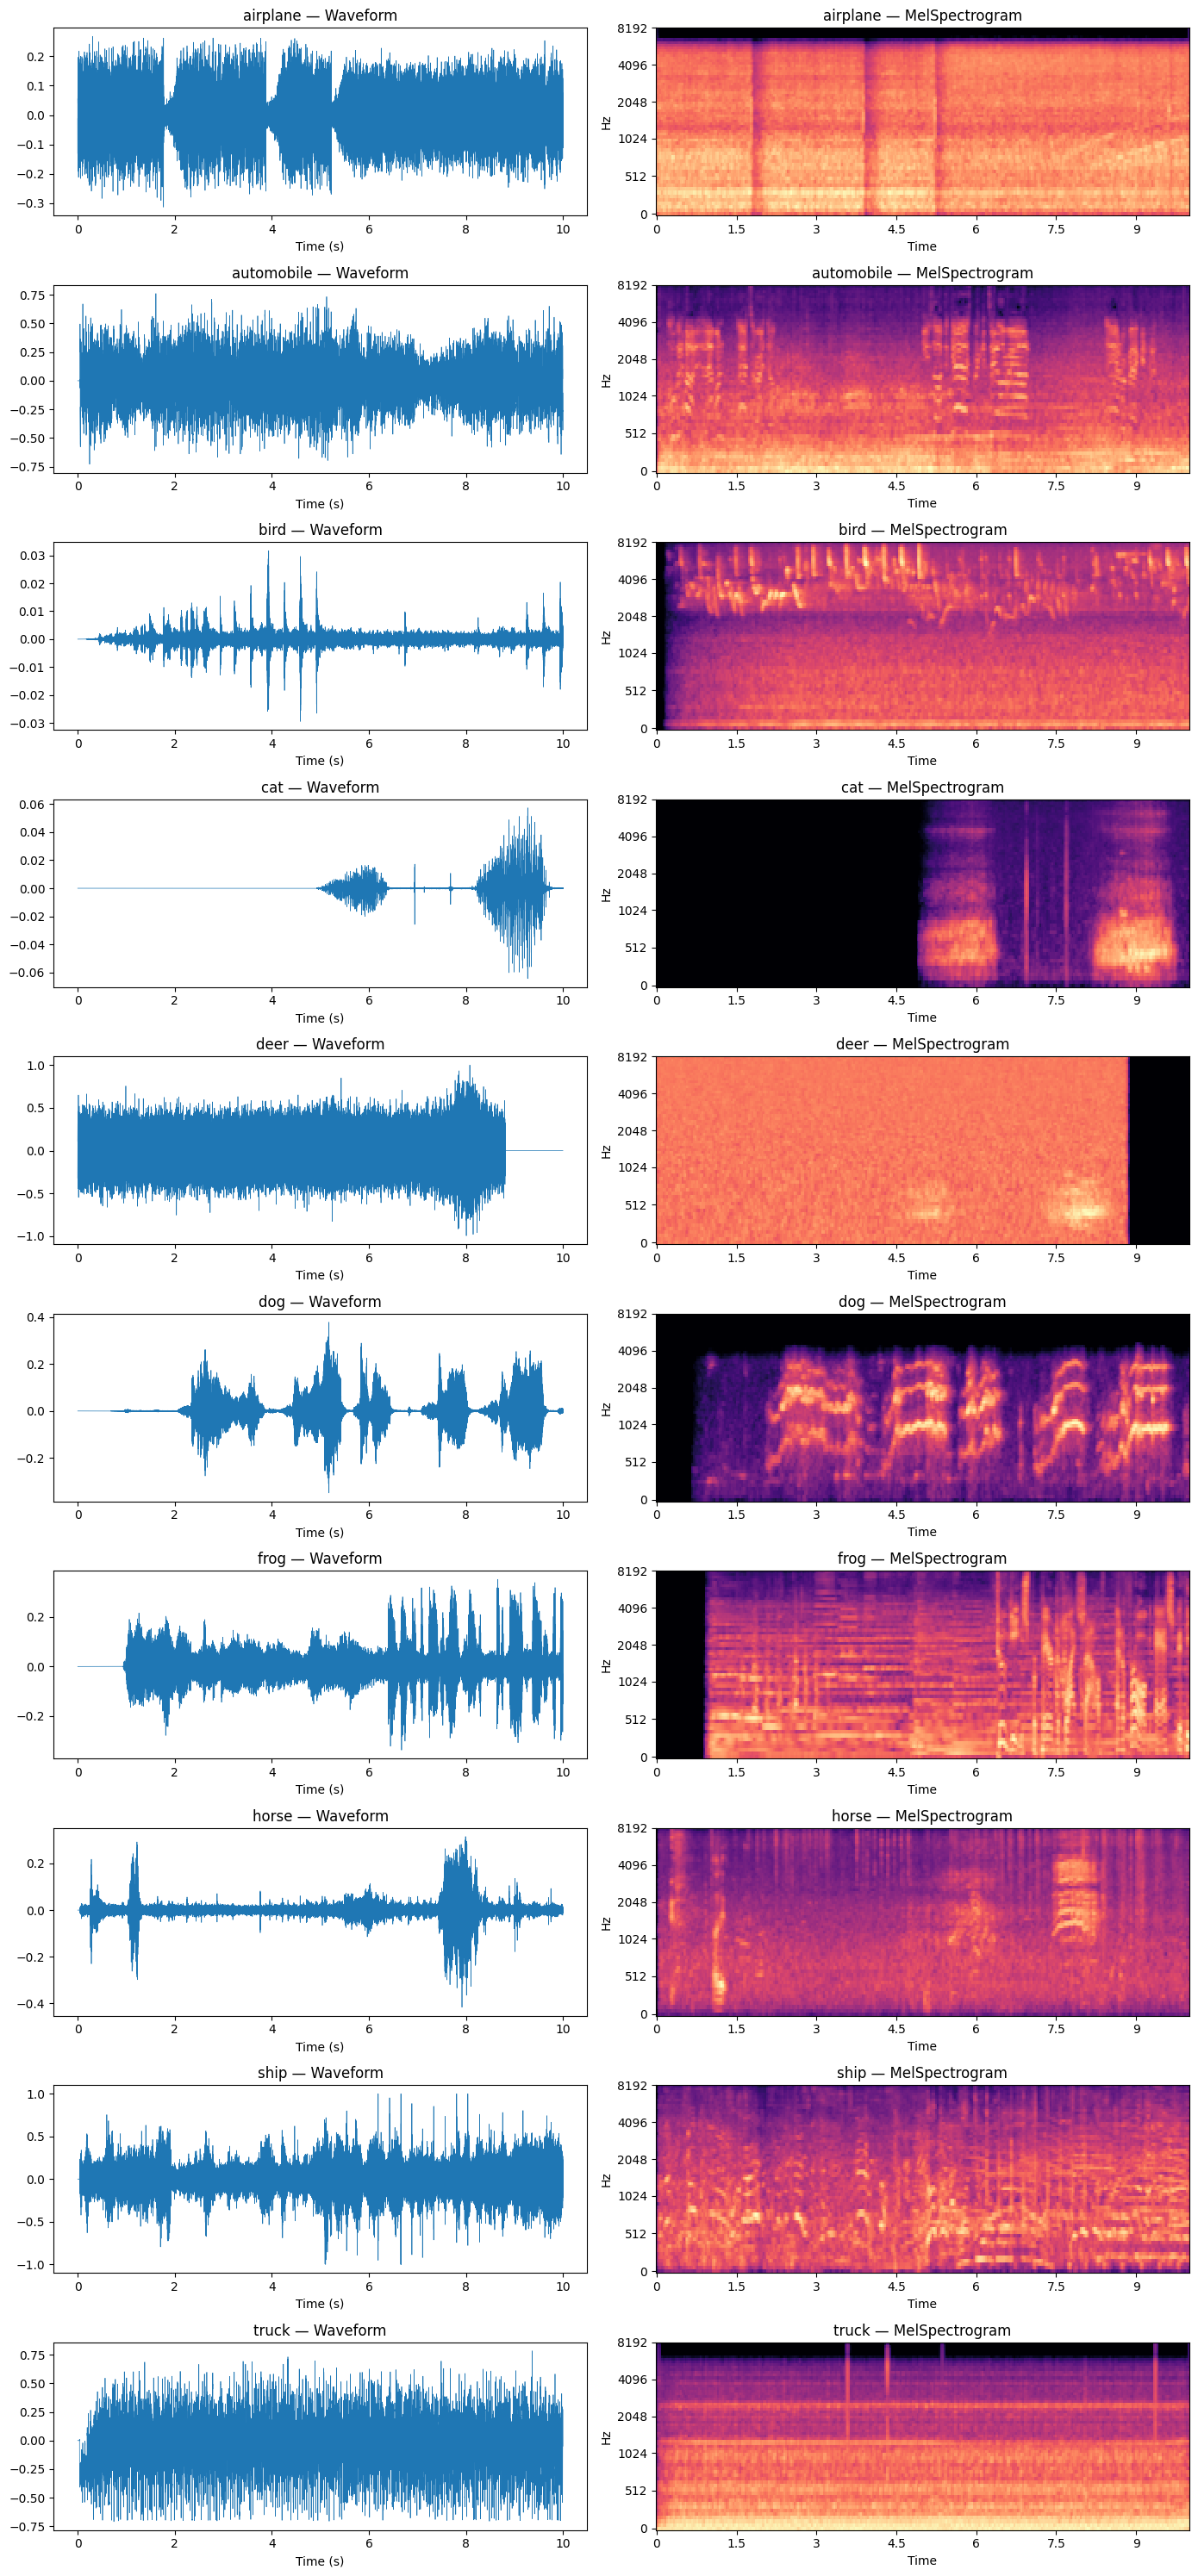

In [7]:
fig, axes = plt.subplots(10, 2, figsize=(14, 30))

for i, cls in enumerate(CIFAR10_CLASSES):
    sample = final_df[final_df['cifar_class'] == cls].iloc[0]
    y, sr  = librosa.load(sample['filepath'], 
                          sr=SAMPLE_RATE, duration=float(DURATION))

    mel    = librosa.feature.melspectrogram(y=y, sr=sr, 
                                             n_mels=64, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Waveform
    axes[i][0].plot(np.linspace(0, len(y)/sr, len(y)), y, linewidth=0.5)
    axes[i][0].set_title(f"{cls} — Waveform")
    axes[i][0].set_xlabel("Time (s)")

    # MelSpectrogram
    librosa.display.specshow(mel_db, sr=sr, x_axis='time',
                             y_axis='mel', ax=axes[i][1], fmax=8000)
    axes[i][1].set_title(f"{cls} — MelSpectrogram")

plt.tight_layout()
plt.show()

## 8. Dataset Summary

In [8]:
print("=" * 50)
print("AUDIOSET DATASET PREPARATION SUMMARY")
print("=" * 50)
print(f"Source:          AudioSet (YouTube clips)")
print(f"Duration:        {DURATION}s per clip")
print(f"Sample rate:     {SAMPLE_RATE}Hz")
print(f"Classes:         10 (CIFAR-10 aligned)")
print(f"Samples/class:   {MAX_PER_CLASS}")
print(f"Total samples:   {len(final_df)}")
print(f"Real audio:      {(~final_df['synthesised']).sum()}")
print(f"Synthesised:     {final_df['synthesised'].sum()} (deer only)")
print(f"Manifest saved:  AudioSet/final_dataset.csv")
print("=" * 50)
print("\nComparison with previous experiments:")
print(f"{'Dataset':<20} {'Samples/class':>15} {'Total':>10}")
print("-" * 47)
print(f"{'ESC-50':<20} {'40':>15} {'400':>10}")
print(f"{'AudioSet':<20} {'100':>15} {'1000':>10}")
print(f"\nNext: 06_a_module_audioset_training.ipynb")
print("Re-run baseline LSTM and Wav2Vec2 on this dataset")
print("Compare results against ESC-50 experiments")

AUDIOSET DATASET PREPARATION SUMMARY
Source:          AudioSet (YouTube clips)
Duration:        10s per clip
Sample rate:     16000Hz
Classes:         10 (CIFAR-10 aligned)
Samples/class:   100
Total samples:   993
Real audio:      893
Synthesised:     100 (deer only)
Manifest saved:  AudioSet/final_dataset.csv

Comparison with previous experiments:
Dataset                Samples/class      Total
-----------------------------------------------
ESC-50                            40        400
AudioSet                         100       1000

Next: 06_a_module_audioset_training.ipynb
Re-run baseline LSTM and Wav2Vec2 on this dataset
Compare results against ESC-50 experiments
